# Sprint 6 - Análisis Exploratorio Inferencial (Ejercicios)

En este caso se busca profundizar en la práctica sobre las **pruebas A/B** mediante tests estadísticos de hipótesis e intervalos de confianza. En concreto veremos una de las principales aplicaciones asociadas a inferencia en el ámbito de negocios: la medición de efectividad de estrategias de marketing.

Para esto, vale introducir el denominado análisis de embudo, que por un lado permite comprender cómo evolucionan las diferentes entidades de un negocio a través de un proceso definido y cuáles son los factores que influyen en su avance o abandono; y por otro caracterizan de mejor forma a dichas entidades en términos de valor para el negocio.

Desde una perspectiva general, toda organización busca que determinadas entidades completen un conjunto de etapas que generan valor para el negocio. Dependiendo del contexto, estas entidades pueden corresponder a clientes potenciales, usuarios de una aplicación, suscriptores de un servicio, productos dentro de una cadena logística, solicitudes de crédito, estudiantes de un programa académico o cualquier otro elemento que transite por un flujo de actividades previamente establecido. El análisis de embudos tiene precisamente como objetivo estudiar ese recorrido y cuantificar el desempeño de cada una de las etapas que lo componen.

La denominación de "embudo" proviene de la representación visual que suele adoptar este tipo de análisis. A medida que las entidades avanzan por las diferentes etapas del proceso, una parte de ellas abandona o no logra completar los requisitos necesarios para continuar. Como consecuencia, el número de entidades presentes en cada fase disminuye progresivamente, generando una forma similar a la de un embudo: una base amplia en las etapas iniciales y una sección más estrecha en las etapas finales. Por ejemplo, dentro de un proceso comercial es habitual observar que un gran número de personas visualiza una campaña publicitaria, una proporción menor manifiesta interés en el producto, una cantidad aún más reducida solicita información adicional y solamente una fracción termina realizando una compra.

Este estudio permite identificar puntos críticos dentro del proceso de negocio. Una caída significativa en una etapa específica puede indicar problemas operativos, barreras para los usuarios, deficiencias en la propuesta de valor o oportunidades de mejora que afectan directamente los resultados de la organización. Por esta razón, el análisis de embudos se ha convertido en una herramienta indispensable para la optimización de procesos y la toma de decisiones basada en datos.

Una de las aplicaciones más importantes del análisis de embudos se encuentra actualmente en los procesos de marketing y ventas. En estos contextos, las organizaciones buscan comprender el denominado viaje del cliente, es decir, el conjunto de interacciones y decisiones que una persona realiza desde el primer contacto con una marca, producto o servicio, hasta la conversión final y su posible fidelización. Analizar este recorrido permite identificar oportunidades para mejorar campañas publicitarias, optimizar canales de adquisición, incrementar conversiones y fortalecer la experiencia de los clientes.

En el presente caso utilizaremos nuestra habilidades en inferencia estadística para tener una visión objetiva respecto a como una estrategia concreta de merketing puede incidir en este viaje del cliente.

## Entendimiento del contexto

La industria de pedidos de comida en línea ha crecido aceleradamente en la última década, impulsada por la digitalización, el uso masivo de teléfonos inteligentes y los cambios en los hábitos de consumo en especial luego de la pandemia del COVID. Plataformas como Uber Eats, DoorDash, Rappi, Glovo y Just Eat han transformado la forma en que los restaurantes se conectan con los clientes, ofreciendo conveniencia, rapidez y una amplia variedad de opciones.

Este sector se apoya fuertemente en la tecnología para ofrecer experiencias rápidas, personalizadas y convenientes. Las plataformas utilizan inteligencia artificial, big data y geolocalización para optimizar rutas de entrega, predecir la demanda y personalizar las recomendaciones según las preferencias del usuario. Además, la automatización de pagos, las interfaces intuitivas y el seguimiento en tiempo real han elevado las expectativas del consumidor en cuanto a eficiencia y transparencia.

En la actualidad, la industria enfrenta diversos desafíos para asegurar la fidelización de usuarios, quienes buscan comodidad, inmediatez y variedad. Valoran poder comparar precios, leer reseñas y repetir pedidos con pocos clicks. La pandemia consolidó el hábito de pedir comida en línea, y aunque el ritmo se estabilizó después, el comportamiento del consumidor sigue orientado hacia la conveniencia digital. Hoy, la fidelidad depende menos de la marca del restaurante y más de la experiencia en las aplicaciones, la rapidez del servicio y los programas de recompensas o membresías.

Ante esta realidad, una empresa que provee este servicio te ha contratado para que le ayudes a evaluar el impacto que tendría un cambio en el diseño y presentación de su aplicación. En concreto, les interesa saber si esta modificación implicará cambios significativos en los niveles de conversión de las distintas etapas del embudo que siguen sus usuarios.

Es importante que sepas que el referido embudo en la aplicación consta de los siguientes 4 eventos:

1. Acceso a pantalla principal de la aplicación.
2. Acceso a la pantalla de productos alimenticios ofertados.
3. Selección de productos y acceso a pantalla de carrito de compras.
4. Pago por productos y servicios de envío y aparición de pantalla de pago exitoso.

Tu objetivo entonces es ejecutar pruebas A/B y determinar si hay de hecho cambios en cada tasa de conversión entre estas etapas ante los cambios de la interfaz de usuario.

También debes saber que la empresa realizó ya un experimento durante 2 semanas en el cual dividió de forma aleatoria a los usuarios de la aplicación en 3 grupos. A dos de estos grupos les mostró la aplicación con los cambios de fuentes deseados, y al tercero le mostró una versión usual de la aplicación.

## Entendimiento de los datos

### Ejercicio 1

Carga la librería **tidyverse** para manipular de mejor forma la información.

In [1]:
# Cargar librerias
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Los registros de ingresos a la aplicación durante estas dos semanas del experimento se encuentran en el archivo [**logs_exp_us.csv**](https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_analytics/refs/heads/main/datasets/logs_exp_us.csv). Carga el archivo y mira su estructura general. 

In [2]:
# Cargar datos
df_regapp <- read_delim(
    "https://raw.githubusercontent.com/jsaraujo5081/material_curso_data_analytics/refs/heads/main/datasets/logs_exp_us.csv", 
    delim = "\t"
)

Rows: 244126 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): EventName
dbl (3): DeviceIDHash, EventTimestamp, ExpId

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
# Mostrar estructura del dataset
glimpse(df_regapp)

Rows: 244,126
Columns: 4
$ EventName      <chr> "MainScreenAppear", "MainScreenAppear", "PaymentScreenS…
$ DeviceIDHash   <dbl> 4.575589e+18, 7.416695e+18, 3.518123e+18, 3.518123e+18,…
$ EventTimestamp <dbl> 1564029816, 1564053102, 1564054127, 1564054127, 1564055…
$ ExpId          <dbl> 246, 246, 248, 248, 248, 248, 246, 246, 247, 246, 247, …


Esta tabla consta de más de 240 mil registros e incluye las siguientes columnas:

* EventName: Nombre del evento que es parte del embudo de usuarios.
* DeviceIDHash: Identificador único de los usuarios.
* EventTimestamp: Marcador temporal del registro en formato UNIX.
* ExpId: Número asociado a los grupos del experimento (246 es el grupo de control, y 247 - 248 son los grupos de tratamiento).

### Ejercicio 2

Explora en profundidad estos datos y cada una de sus columnas.

In [4]:
# Generar muestra del dataset
df_regapp %>% sample_n(10)

EventName,DeviceIDHash,EventTimestamp,ExpId
<chr>,<dbl>,<dbl>,<dbl>
CartScreenAppear,4.435880e+18,1564762134,246
MainScreenAppear,3.385300e+16,1565094098,246
MainScreenAppear,7.512586e+18,1565114910,246
MainScreenAppear,4.557913e+18,1565119889,248
OffersScreenAppear,5.545199e+18,1565011324,248
OffersScreenAppear,4.462438e+18,1565015393,246
MainScreenAppear,8.732983e+17,1565194013,246
PaymentScreenSuccessful,3.337472e+18,1565176732,246
CartScreenAppear,8.131554e+18,1565114766,248


In [5]:
# Verificar si existen valores ausentes
print(colSums(is.na(df_regapp)))

     EventName   DeviceIDHash EventTimestamp          ExpId 
             0              0              0              0 


In [6]:
# Mostrar eventos existentes
df_regapp["EventName"] %>% unique()

EventName
<chr>
MainScreenAppear
PaymentScreenSuccessful
CartScreenAppear
OffersScreenAppear
Tutorial


In [7]:
# Mostrar grupos existentes
df_regapp["ExpId"] %>% unique()

ExpId
<dbl>
246
248
247


In [8]:
# Generar un resumen estadistico de Eventtimestamp
options(scipen = 999) # ESto evita que los valores salgan con notacion cientifica
df_regapp["EventTimestamp"] %>% summary()

 EventTimestamp      
 Min.   :1564029816  
 1st Qu.:1564756580  
 Median :1564919395  
 Mean   :1564913916  
 3rd Qu.:1565074511  
 Max.   :1565212517  

In [9]:
# Verificar si existen observacione duplicadas
sum(duplicated(df_regapp))

[1] 413

### Ejercicio 3 

Define un plan de acción coherente para preparar los datos a partir de este entendimiento.

**PLAN DE ACCIÓN PARA PREPARACIÓN DE DATOS**

| # | Acción |
| ---- | ---- |
| 1 | Se deben ajustar los nombres de las columnas a formato *snake_case*. Además convendría cambiar los nombres del dataset por unos más didácticos y comprensibles. |
| 2 | La columna que registra el marcador temporal debe cambiarse a un formato de fecha para a partir de aquí extraer el componente de la fecha (yyyy-mm-dd) en que se dio el experimento. | 
| 3 | Existe el evento "Tutorial" que corresponde seguramente a usuarios que ingresaron a la pantalla de ayuda de la aplicación. Este evento no es parte del embudo por lo que debería eliminarse. |
| 4 | Se podría modificar los valores de la columna del grupo experimental a fin de hacerlos más comprensibles (A, B1 y B2). |
| 5 | Se deben eliminar los valores duplicados puesto que los mismos representarían información errónea que sesgaría los análisis posteriores. |

## Preparación de datos

### Ejercicio 1 

Ejecuta el plan de acción que definiste de manera ordenada.

In [10]:
# Ajustar los nombres de las columnas
names(df_regapp) <- c("event", "user", "timestamp", "group")
glimpse(df_regapp)

Rows: 244,126
Columns: 4
$ event     <chr> "MainScreenAppear", "MainScreenAppear", "PaymentScreenSucces…
$ user      <dbl> 4575588528974610432, 7416695313311560704, 351812309130700544…
$ timestamp <dbl> 1564029816, 1564053102, 1564054127, 1564054127, 1564055322, …
$ group     <dbl> 246, 246, 248, 248, 248, 248, 246, 246, 247, 246, 247, 248, …


In [11]:
# Cambiar el tipo de la columna timestamp
df_regapp <- df_regapp %>%
mutate(timestamp = as_datetime(timestamp))

df_regapp["timestamp"] %>% summary()

   timestamp                     
 Min.   :2019-07-25 04:43:36.00  
 1st Qu.:2019-08-02 14:36:20.25  
 Median :2019-08-04 11:49:55.00  
 Mean   :2019-08-04 10:18:35.83  
 3rd Qu.:2019-08-06 06:55:11.00  
 Max.   :2019-08-07 21:15:17.00  

In [12]:
# Extraer componente de dia del experimento
df_regapp <- df_regapp %>%
mutate(date = date(timestamp))

df_regapp %>% sample_n(5)

event,user,timestamp,group,date
<chr>,<dbl>,<dttm>,<dbl>,<date>
MainScreenAppear,7311730072021703680,2019-08-02 18:43:04,247,2019-08-02
MainScreenAppear,6471118158986316800,2019-08-01 12:38:05,247,2019-08-01
MainScreenAppear,2401361659688185344,2019-08-02 11:11:48,248,2019-08-02
MainScreenAppear,543084593576456128,2019-08-07 13:53:27,248,2019-08-07
CartScreenAppear,3198863056321683456,2019-08-03 15:56:39,248,2019-08-03


In [13]:
# Eliminar evento "Tutorial"
df_regapp <- df_regapp %>%
filter(event != "Tutorial")

dim(df_regapp)

[1] 243074      5

In [14]:
# Cambiar nombres de grupos
df_regapp <- df_regapp %>%
mutate(group = if_else(
    group == 246,
    "A",
    if_else(
        group == 247,
        "B1",
        "B2"
    )
))

df_regapp["group"] %>% unique()

group
<chr>
A
B2
B1


In [15]:
# Eliminar duplicados del dataset
df_regapp <- df_regapp %>%
filter(!duplicated(.))

sum(duplicated(df_regapp))

[1] 0

## Análisis exploratorio descriptivo

### Ejercicio 1

Estudia el comportamiento de la cantidad de registros (observaciones) respecto a los eventos, los grupos y los días en que se realizó el experimento.

In [16]:
# Mostrar registros en la aplicación por evento
df_regapp %>%
count(event, name = "obs") %>%
arrange(desc(obs))

event,obs
<chr>,<int>
MainScreenAppear,119101
OffersScreenAppear,46808
CartScreenAppear,42668
PaymentScreenSuccessful,34118


In [17]:
# Mostrar registros en la aplicación por grupo
df_regapp %>%
count(group, name = "obs")

group,obs
<chr>,<int>
A,79863
B1,77605
B2,85227


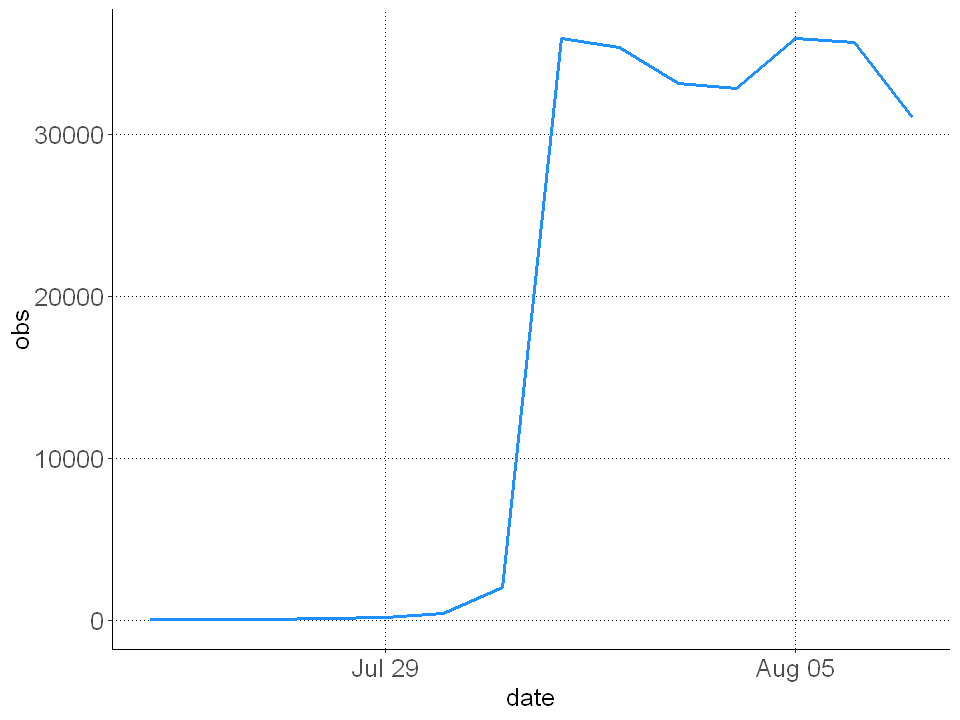

In [18]:
# Mostrar registros en la aplicación por dia
reg_por_dia <- df_regapp %>%
count(date, name = "obs")

options(repr.plot.width = 8, repr.plot.height = 6)
ggplot(
    data = reg_por_dia,
    mapping = aes(
        x = date,
        y = obs
    )
) +
geom_line(
    color = "dodgerblue",
    linewidth = 1
) +
theme_classic() +
theme(
    panel.grid.major = element_line(color = "black", linetype = "dotted"),
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 15)
)

Elimina los registros de la primera semana del experimento puesto que de tu estudio se desprende que en este tiempo practicamente no se dieron observaciones significativas.

In [19]:
df_regapp <- df_regapp %>%
filter(date >= "2019-08-01")

df_regapp["timestamp"] %>% summary()

   timestamp                     
 Min.   :2019-08-01 00:08:00.00  
 1st Qu.:2019-08-02 15:29:38.00  
 Median :2019-08-04 12:31:04.00  
 Mean   :2019-08-04 11:34:56.88  
 3rd Qu.:2019-08-06 07:23:45.00  
 Max.   :2019-08-07 21:15:17.00  

### Ejercicio 2

Estudia el comportamiento de la cantidad de usuarios respecto a eventos y grupos, tanto de forma individual como combinando estas dimensiones.

In [20]:
# Mostrar usuarios por evento
df_regapp %>%
group_by(event) %>%
summarise(users = n_distinct(user)) %>%
ungroup() %>%
arrange(desc(users))

event,users
<chr>,<int>
MainScreenAppear,7419
OffersScreenAppear,4593
CartScreenAppear,3734
PaymentScreenSuccessful,3539


In [21]:
# Mostrar usuarios por grupo
df_regapp %>%
group_by(group) %>%
summarise(users = n_distinct(user)) %>%
ungroup()

group,users
<chr>,<int>
A,2483
B1,2512
B2,2535


In [22]:
# Mostrar usuarios por evento y grupo
df_regapp %>%
group_by(event, group) %>%
summarise(users = n_distinct(user)) %>%
ungroup() %>%
pivot_wider(
    names_from = "group",
    values_from = "users"
) %>%
arrange(desc(A))

`summarise()` has grouped output by 'event'. You can override using the
`.groups` argument.


event,A,B1,B2
<chr>,<int>,<int>,<int>
MainScreenAppear,2450,2476,2493
OffersScreenAppear,1542,1520,1531
CartScreenAppear,1266,1238,1230
PaymentScreenSuccessful,1200,1158,1181


¿Puedes ya observar los embudos en cada uno de los grupos? Evidentemente existen más usuarios al inicio del proceso cuando llegan a la app, que al final cuando se ejecuta la compra.

Estudia ahora el comportamiento de la cantidad de usuarios respecto a grupos y dias, combinando estas dimensiones.

`summarise()` has grouped output by 'date'. You can override using the
`.groups` argument.


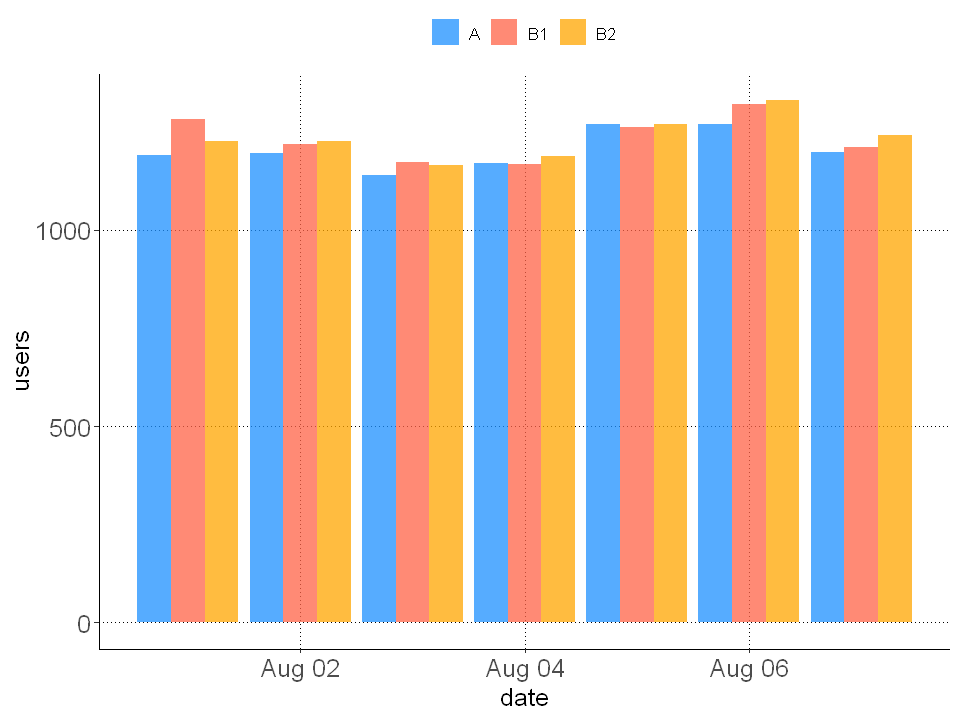

In [23]:
usr_por_diagrupo <- df_regapp %>%
group_by(date, group) %>%
summarise(users = n_distinct(user)) %>%
ungroup()

ggplot(
    data = usr_por_diagrupo,
    mapping = aes(
        x = date,
        y = users,
        fill = group
    )
) +
geom_col(
    position = "dodge",
    alpha = 0.75
) +
scale_fill_manual(values = c("dodgerblue", "tomato", "orange")) +
theme_classic() +
theme(
    panel.grid.major = element_line(color = "black", linetype = "dotted"),
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 15),
    legend.text = element_text(size = 10),
    legend.title = element_blank(),
    legend.position = "top"
)

### Ejercicio 3

Estudia el comportamiento de la tasa de conversión de usuarios entre etapas del embudo tanto a nivel general como por grupos del experimento. A estas últimas guardalas en una variable llamada `tasas_grupos`.

In [24]:
# Estimar tasas de conversion general
df_regapp %>%
group_by(event) %>%
summarise(users = n_distinct(user)) %>%
ungroup() %>%
arrange(desc(users)) %>%
mutate(conv_rate = 100 * users/max(users))

event,users,conv_rate
<chr>,<int>,<dbl>
MainScreenAppear,7419,100.00000
OffersScreenAppear,4593,61.90861
CartScreenAppear,3734,50.33023
PaymentScreenSuccessful,3539,47.70185


In [25]:
# Estimar tasas de conversión por grupo
tasas_grupos <- df_regapp %>%
group_by(event, group) %>%
summarise(users = n_distinct(user)) %>%
ungroup() %>%
group_by(group) %>%
mutate(conv_rate = users / max(users), .keep = "unused") %>%
pivot_wider(
    names_from = "group",
    values_from = "conv_rate"
) %>%
arrange(desc(A))

tasas_grupos

`summarise()` has grouped output by 'event'. You can override using the
`.groups` argument.


event,A,B1,B2
<chr>,<dbl>,<dbl>,<dbl>
MainScreenAppear,1.0000000,1.0000000,1.0000000
OffersScreenAppear,0.6293878,0.6138934,0.6141195
CartScreenAppear,0.5167347,0.5000000,0.4933815
PaymentScreenSuccessful,0.4897959,0.4676898,0.4737264


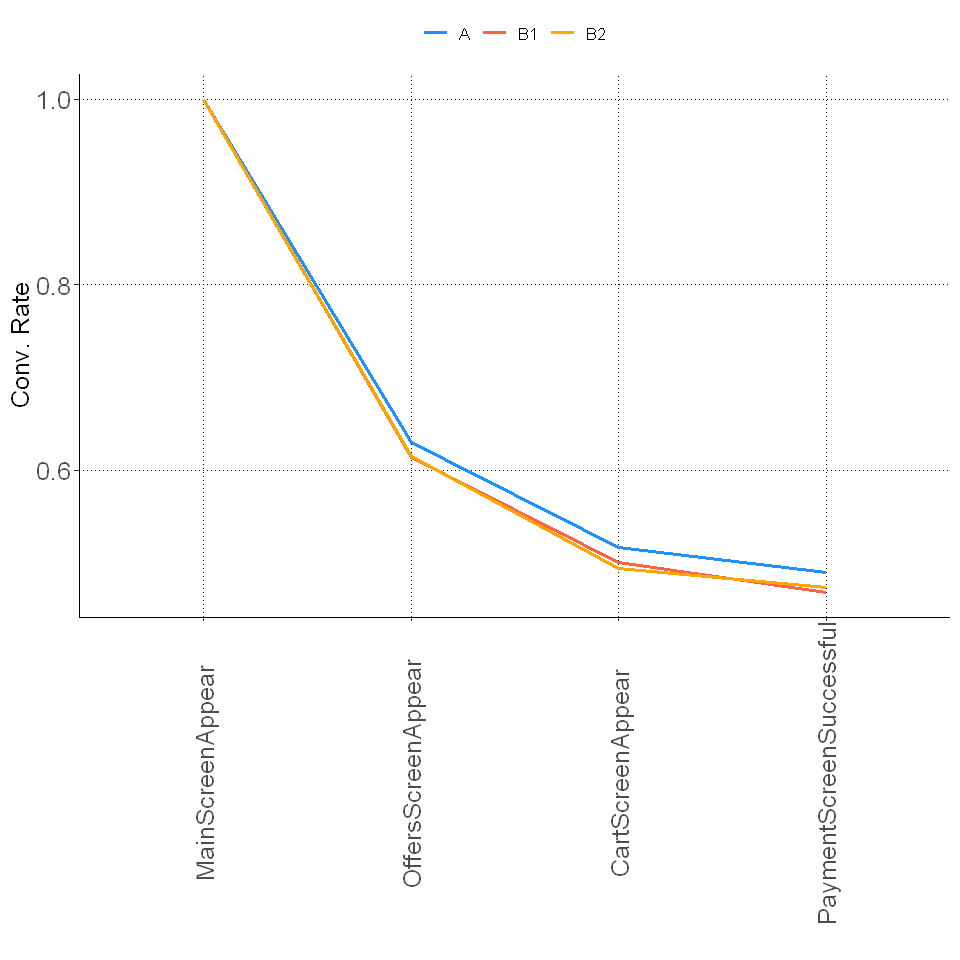

In [26]:
# Visualizar tasas de conversion por grupos
options(repr.plot.width = 8, repr.plot.height = 8)
ggplot(data = tasas_grupos) +
geom_line(
    mapping = aes(
        x = reorder(event, desc(A)),
        y = A,
        group = 1,
        color = "A"
    ),
    linewidth = 1
) +
geom_line(
    mapping = aes(
        x = reorder(event, desc(B1)),
        y = B1,
        group = 1,
        color = "B1"
    ),
    linewidth = 1
) +
geom_line(
    mapping = aes(
        x = reorder(event, desc(B2)),
        y = B2,
        group = 1,
        color = "B2"
    ),
    linewidth = 1
) +
scale_color_manual(values = c("dodgerblue", "tomato", "orange")) +
labs(
    x = "",
    y = "Conv. Rate"
) +
theme_classic() +
theme(
    panel.grid.major = element_line(color = "black", linetype = "dotted"),
    plot.title = element_text(size = 20, hjust = 0.5),
    axis.text = element_text(size = 15),
    axis.text.x = element_text(angle = 90, vjust = 0.5),
    axis.title = element_text(size = 15),
    legend.text = element_text(size = 10),
    legend.title = element_blank(),
    legend.position = "top"
)

Genera una conclusión relevante respecto a las tasas de conversión observadas y el potencial efecto del experimento realizado en la interfaz del usuario de la aplicación.

**CONCLUSIONES**

| # | Conclusión |
| ---- | ---- |
| 1 | Al parecer existiría un posible efecto negativo en los niveles de conversión de las distintas etapas producto de la modificación en la aplicación por la estrategia de marketing implementada. Para confirmar esta hipótesis es importante realizar los correspondientes test estadísticos de una prueb A/B. |

## Análisis exploratorio inferencial

### Ejercicio 1

En primera instancia conviene evaluar si el comportamiento de los dos grupos de tratamiento son iguales, ya que esto daría validez al experimento realizado. Empieza por la primera etapa de conversión en el embudo ("OffersScreenAppear") definiendo la hipótesis a probar y luego ejecutando el test estadístico correspondiente a un 10% de significancia. Para cumplir con esto, aplica la función `prop.test`.

| Hipótesis | Postulado |
| ---- | ---- |
| Nula | La tasa de conversión en OffersScreenAppear del grupo B1 es IGUAL a la del grupo B2. |
| Alternativa | La tasa de conversión en OffersScreenAppear del grupo B1 es DISTINTA a la del grupo B2. |

In [27]:
# Extraer muestras de ambos grupos
muestra_1 <- df_regapp %>%
filter(group == "B1")

muestra_2 <- df_regapp %>%
filter(group == "B2")

In [28]:
# Obtener cantidad de usuarios totales
tot_users <- c(n_distinct(muestra_1$user), n_distinct(muestra_2$user))

In [29]:
# Obtener cantidad de casos convertidos
users_1 <- muestra_1 %>%
filter(event == "OffersScreenAppear") %>%
summarise(n_distinct(user)) %>%
pull()

users_2 <- muestra_2 %>%
filter(event == "OffersScreenAppear") %>%
summarise(n_distinct(user)) %>%
pull()

suc_users <- c(users_1, users_2)

In [30]:
# Extraer valor p
p_value <- prop.test(
    x = suc_users,
    n = tot_users,
    alternative = "two.sided",
    correct = FALSE
)$p.value

print(paste(
    "Valor p: ", 
    formatC(p_value * 100, format = "f", digits = 1),
    "%",
    sep = ""
))

[1] "Valor p: 93.3%"


In [31]:
# Aplicar criterio de decision
if (p_value < 0.1) {
    print("Rechazo H_0")
} else {
    print("No Rechazo H_0")
}

[1] "No Rechazo H_0"


Ahora bien, para complementar este test podemos realizar un análisis de intervalos de confianza. Estima entonces el intervalo correspondiente para la diferencia entre tasas de conversión de ambos grupos utilizando la función. Establece una confiablidad del 90% (equivalente a 100% menos el nivel de significancia del test anterior).

In [32]:
# Calcular intervalos de confianza para diferencia entre ambos grupos
props <- suc_users / tot_users 

conf <- 0.9
z_val <- qnorm(conf)

error <- sqrt((props[1] * (1 - props[1]) / tot_users[1]) + (props[2] * (1 - props[2]) / tot_users[2]))

lower_bound <- (props[1] - props[2]) - error * z_val
upper_bound <- (props[1] - props[2]) + error * z_val
print(paste(
    "IC al 95% para diferencia entre grupos: [",
    formatC(lower_bound * 100, format = "f", digits = 1),
    "%, ",
    formatC(upper_bound * 100, format = "f", digits = 1),
    "%]",
    sep = ""
))

[1] "IC al 95% para diferencia entre grupos: [-1.6%, 1.9%]"


### Ejercicio 2

Repite este test para las otras etapas del embudo. Te recomiendo que construyas una función considerando que es un proceso redundante en la que generes el test de hipótesis y el intervalo de confianza correspondiente. 

In [33]:
# Funcion para desarrollar inferencia
fun_testab <- function (
    group_1, 
    group_2,
    stage, 
    alt = "two.sided", 
    alpha = 0.1
) {

    # Extraer muestras de ambos grupos
    muestra_1 <- df_regapp %>%
    filter(group == group_1)

    muestra_2 <- df_regapp %>%
    filter(group == group_2)

    # Obtener cantidad de usuarios totales
    tot_users <- c(n_distinct(muestra_1$user), n_distinct(muestra_2$user))
    
    # Obtener cantidad de casos convertidos
    users_1 <- muestra_1 %>%
    filter(event == stage) %>%
    summarise(n_distinct(user)) %>%
    pull()

    users_2 <- muestra_2 %>%
    filter(event == stage) %>%
    summarise(n_distinct(user)) %>%
    pull()

    suc_users <- c(users_1, users_2)

    # Extraer valor p
    p_value <- prop.test(
        x = suc_users,
        n = tot_users,
        alternative = alt,
        correct = FALSE
    )$p.value

    print(paste(
        "Valor p: ", 
        formatC(p_value * 100, format = "f", digits = 1),
        "%",
        sep = ""
    ))

    # Aplicar criterio de decision
    if (p_value < alpha) {
        print("Rechazo H_0")
    } else {
        print("No Rechazo H_0")
    }

    # Calcular intervalos de confianza para diferencia entre ambos grupos
    props <- suc_users / tot_users 

    conf <- 0.9
    z_val <- qnorm(conf)

    error <- sqrt((props[1] * (1 - props[1]) / tot_users[1]) + (props[2] * (1 - props[2]) / tot_users[2]))

    lower_bound <- (props[1] - props[2]) - error * z_val
    upper_bound <- (props[1] - props[2]) + error * z_val
    print(paste(
        "IC al 95% para diferencia entre grupos: [",
        formatC(lower_bound * 100, format = "f", digits = 1),
        "%, ",
        formatC(upper_bound * 100, format = "f", digits = 1),
        "%]",
        sep = ""
    ))

}

In [34]:
# Validar funcion para etapa OffersScreenAppear
fun_testab("B1","B2","OffersScreenAppear")

[1] "Valor p: 93.3%"
[1] "No Rechazo H_0"
[1] "IC al 95% para diferencia entre grupos: [-1.6%, 1.9%]"


In [35]:
# Ejecutar funcion para etapa CartScreenAppear
fun_testab("B1","B2","CartScreenAppear")

[1] "Valor p: 58.8%"
[1] "No Rechazo H_0"
[1] "IC al 95% para diferencia entre grupos: [-1.0%, 2.6%]"


In [36]:
# Ejecutar funcion para etapa PaymentScreenSuccessful
fun_testab("B1","B2","PaymentScreenSuccessful")

[1] "Valor p: 72.8%"
[1] "No Rechazo H_0"
[1] "IC al 95% para diferencia entre grupos: [-2.3%, 1.3%]"


Acabamos de comprobar que ambos grupos de tratamiento tienen niveles estadísticamente iguales por lo que consolida ambos grupos de tratamiento en uno solo de nombre "B".

In [37]:
df_regapp <- df_regapp %>%
mutate(group = if_else(
    group %in% c("B1", "B2"),
    "B",
    group
))

### Ejercicio 3

Ejecuta ahora las pruebas estadísticas para ratificar la hipótesis de efectos negativos en las tasas de conversión por el cambio realizado la aplicación. Empieza definiendo los postulados correspondientes. 

**HIPÓTESIS A EVALUAR**

| Hipótesis | Postulado |
| ---- | ---- |
| Nula | La tasa de conversión en el evento seleccionado del grupo A es IGUAL a la de los grupos de tratamiento. |
| Alternativa | La tasa de conversión en el evento seleccionado del grupo A es MAYOR a la de los grupos de tratamiento. |

In [38]:
# Ejecutar prueba para etapa OffersScreenAppear
fun_testab("A","B","OffersScreenAppear", alt = "greater")

[1] "Valor p: 8.4%"
[1] "Rechazo H_0"
[1] "IC al 95% para diferencia entre grupos: [0.1%, 3.2%]"


In [39]:
# Ejecutar prueba para etapa CartScreenAppear
fun_testab("A","B","CartScreenAppear", alt = "greater")

[1] "Valor p: 4.4%"
[1] "Rechazo H_0"
[1] "IC al 95% para diferencia entre grupos: [0.5%, 3.7%]"


In [40]:
# Ejecutar prueba para etapa PaymentScreenSuccessful
fun_testab("A","B","PaymentScreenSuccessful", alt = "greater")

[1] "Valor p: 5.2%"
[1] "Rechazo H_0"
[1] "IC al 95% para diferencia entre grupos: [0.4%, 3.6%]"


Para concluir con tu análisis, genera conclusiones relevantes asociadas al caso estudiado. 

**CONCLUSIONES**

| # | Conclusión |
| ---- | ---- |
| 1 | A un nivel de significancia del 10% se evidencian efectos negativos ante los cambios realizados en la aplicación de la empresa. Lo anterior tiene especial énfasis en las últimas etapas del embudo que corresponden a llegar al carrito de compras y a ejecutar el pago. Se recomienda por tanto una evaluación por parte de la empresa para identificar de qué manera la nueva interfaz de usuario está afectando en los procesos de pago y de ser el caso, mantener en esta etapa la versión previa de la app. |
| 2 | En todo caso vale hacer referencia a las limitaciones encontradas durante el análisis. Por una parte, se tuvieron que excluir datos de una semana entera del experimento lo cual podría restar confiabilidad y robustez a los resultados. Además. los efectos encontrados se los obtiene a significancias del 10% producto de las limitaciones referidas en los datos. Si se diera una mayor rigurosidad a los test, las conclusiones alcanzadas podrían cambiar. |